# History Matching (Manual Configuration)

The history matching library can be used in a _manual_ mode, in which the user has control over the selection of emulators and their corresponding emulation targets or features, or _automatic_ mode, in which the selection of emulators and their targets is done internally within each history matching iteration without any intervention from the user.

This notebook shows how to use history matching in manual mode. It describes different ways of interacting with the library to run single or multiple history matching iterations, as well as how to inspect the performance of the trained emulators.

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. In addition, we need to import the `history_matching` package.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching as hm

%matplotlib inline

## Example scenario: a stochastic SIR model

Let's define a stochastic SIR model using the Tao-leap algorithm. This is the model we will calibrate using History Matching. Furthermore, we will use this model to generate synthetic data. Our calibration process will try to recover the parameters that generated the synthetic data.

### Model definition

In [2]:
class SIR:
    """ A stochastic SIR model. 
    """
    def __init__( self, 
                  beta=1.2,  gamma=0.3,        # transition rates
                  s0=990,  i0=10,  r0=0,       # initial conditions
                  n_days=20,                   # number of days to simulate
                  step=0.1,                    # step size in days (<=1)
                  seed=None,                   # random number seed
                 ):
        """ Create and initialize the SIR model.
        
        Args:
            beta   : Transmission rate (>0).
            gamma  : Inverse of the average transmission period (>0).
            s0     : Initial number of succeptible individuals (non-negative 
                     integer).
            i0     : Initial number of infected individuals (non-negative int).
            r0     : Initial number of recovered individuals (non-negative int).
            n_days : Number of days to simulate (positive integer).
            step   : Step size in days (integer between 0 and 1).
            seed   : Seed for the random number generator.
        """
        # Verify inputs
        assert( beta > 0 )
        assert( gamma > 0 )
        assert( s0 >= 0 )
        assert( i0 >= 0 )
        assert( r0 >= 0 )
        assert( n_days > 0 )
        assert( step > 0 )
        assert( step <= 1 )
        
        # Initialize variables
        self.beta = beta
        self.gamma = gamma
        self.s0 = int( s0 )
        self.i0 = int( i0 )
        self.r0 = int( r0 )
        self.n_days = int( n_days )
        self.step = step
        self.seed = seed
        self.simulation_complete = False

    
    def run( self ):
        """ Run the simulation and return S, I, and R arrays.
        """    
        # Initialization
        n_steps = math.ceil( (self.n_days-1)/self.step )
        steps_per_day = int( 1/self.step )
        N = self.s0 + self.i0 + self.r0    # population size             
        
        s = np.zeros( n_steps+1, dtype=int )
        i = np.zeros( n_steps+1, dtype=int )
        r = np.zeros( n_steps+1, dtype=int )        
        s[0] = self.s0
        i[0] = self.i0
        r[0] = self.r0

        s_daily = np.zeros( self.n_days, dtype=int )
        i_daily = np.zeros( self.n_days, dtype=int )
        r_daily = np.zeros( self.n_days, dtype=int )
        s_daily[0] = s[0]
        i_daily[0] = i[0]
        r_daily[0] = r[0]

        if self.seed is not None:
            np.random.seed( seed=self.seed )

        # Compute events per time step
        for j in range(1, n_steps+1):
            lambda_transmission = ( self.beta * s[j-1] * i[j-1] / N ) * self.step
            lambda_recovery = self.gamma * i[j-1] * self.step
                       
            delta_Mt = np.random.poisson( lambda_transmission )
            delta_Mr = np.random.poisson( lambda_recovery )
            
            s[j] = max( s[j-1] - delta_Mt           , 0 )
            i[j] = max( i[j-1] + delta_Mt - delta_Mr, 0 )
            r[j] = r[j-1] + delta_Mr

        # Count events per day
        for j in range(1, self.n_days):
            k = j*steps_per_day
            s_daily[j] = s[k]
            i_daily[j] = i[k]
            r_daily[j] = r[k]
        
        # Finalize and return
        self.s = s_daily
        self.i = i_daily
        self.r = r_daily
        self.simulation_complete = True
        return s_daily, i_daily, r_daily
    

    def get_incidence( self ): 
        """ Return array with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        n = len(self.i)
        incidence = np.zeros(n)
        incidence[0] = 0
        for j in range(1, n):
            incidence[j] = self.s[j-1] - self.s[j]
        return incidence


    def plot( self ): 
        """ Display figure with S, I, and R curves.
        """
        if not self.simulation_complete:
            self.run()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, self.s, 'g')
        plt.plot( x, self.i, 'r')
        plt.plot( x, self.r, 'b')
        plt.legend(['S', 'I', 'R'])
        plt.ylabel('cases')
        plt.xlabel('days')
        plt.title( title )
        plt.grid(linestyle=':')
 

    def plot_incidence( self ): 
        """ Display figure with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        incidence = self.get_incidence()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, incidence, 'b' )
        plt.ylabel('new cases')
        plt.xlabel('days')
        plt.title(title)
        plt.grid(linestyle=':')

### Running our model

Our model should be easy to run. Let's try it with a few different parameters:

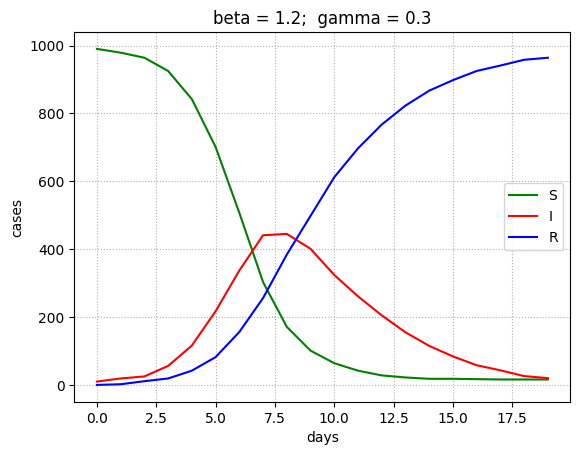

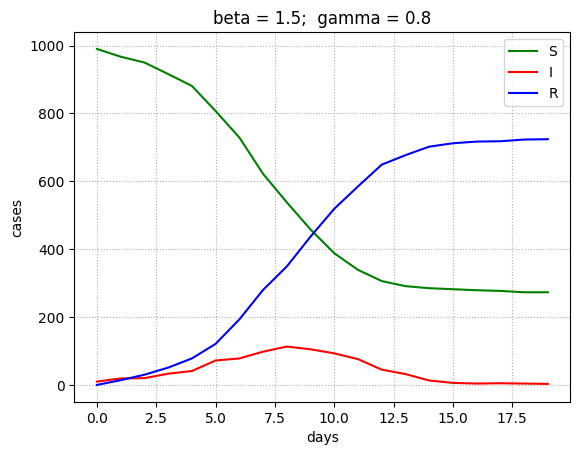

In [3]:
sim1 = SIR()
sim2 = SIR( beta=1.5, gamma=0.8 )
sim1.plot()
sim2.plot()

### Synthetic data

Next we generate synthetic data for the demonstration of the History Matching (HM) algorithm. We define specific values of the `beta` and `gamma` parameters. We will later use to recover (i.e., estimate) those parameters.

In [4]:
# Define model parameters
beta_true = 1.3
gamma_true = 0.5
rand_seed = 0
population_size = 10_000
n_seed_infections = 100

In [5]:
# Run the simulation
true_model = SIR( beta  = beta_true,
                  gamma = gamma_true,
                  s0    = population_size - n_seed_infections,
                  i0    = n_seed_infections,
                  seed  = rand_seed
                 )
S, I, R = true_model.run()

In [6]:
# Generate simulated observation data
incidence_data = true_model.get_incidence()
data = pd.DataFrame( { 'day' : range(0,len(incidence_data)), 
                       'incidence' : incidence_data
                      } ).set_index('day')

Let's quickly glance at our data:

In [7]:
data.head()

,incidence
day,
0,0.0
1,177.0
2,415.0
3,762.0
4,1246.0


<Axes: xlabel='day'>

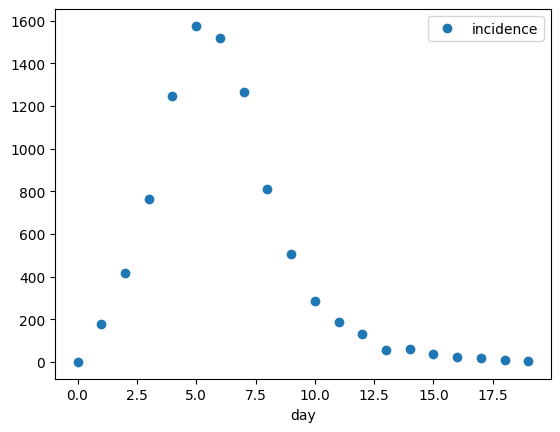

In [8]:
data.plot( style='o' )

## Running a History Matching iteration

### Iteration parameters

There are two parameters that are needed for running a history matching iteration, namely:
- `parameter_space`, which defines the name of our model parameters as well as their corresponding search intervals; and
- `observations`, which contain our observation data.

Let's see how to define each of them.

#### `parameter_space`

This parameter is a dataframe with one row for each one of the parameters, the index column containing the name of each parameters, and two data columns named "minimum" and "maximum" that contain the corresponding lower and upper bound for the parameters. In our example, we can define it as follows:

In [9]:
parameter_space = pd.DataFrame( { # name      ,   min , max
                                  'beta'      : [ 0.01, 5.0 ],
                                  'gamma'     : [ 0.1 , 1.0 ],
                                  #'rand_seed' : [ 0   , 1e5 ]
                                 }, index = ['minimum', 'maximum']
                               ).transpose()
parameter_space.index.name = 'parameter'
parameter_space.head()

,minimum,maximum
parameter,,
beta,0.01,5.0
gamma,0.10,1.0


#### `observations`

The observations data is defined as a datrame with 3 columns for each sample point, namely: "feature", "mean", and "variance". The "feature" defines the name of the sample point. This is how we can define it in our example: 

In [10]:
observations = pd.DataFrame()
observations['feature'] = 'incidence_' + data.index.astype(str)
observations['mean'   ] = data['incidence']
observations['variance'] = 100 #np.maximum( 20, 0.2*data['incidence'] )
observations.head()

,feature,mean,variance
0,incidence_0,0.0,100
1,incidence_1,177.0,100
2,incidence_2,415.0,100
3,incidence_3,762.0,100
4,incidence_4,1246.0,100


### Interacting with the model

There are two ways of interacting with the model: (1) we can provide a wrapper function that receives a set of sample points, runs the model, and return the simulation results for that set of sample points; and (2) we can simply get the set of sample points as a .csv file, run the model, and save the simulation results in another .csv file to be ingested by the history matching function.

In both cases, both the set of sample points and the simulation results have a very specific format. The input sample points should be specified as a dataframe (or table) with rows corresponding to individual sets of points, and columns containing the values for each of the model parameters. The simulation results should be defined as a dataframe (or table) with each row containing the simulation result for the corresponding row in the input sample points, and with each column corresponding to individual outputs of the model.

Let's see these data formats as we build a wrapper function for history matching.

In [11]:
def sir_model_wrapper( points: pd.DataFrame ) -> pd.DataFrame:

    # Run simulations
    #results = pd.DataFrame()
    results = []

    for index, parameters in enumerate(points.itertuples()):

        this_run = SIR( beta  = parameters.beta,
                        gamma = parameters.gamma,
                        s0    = population_size - n_seed_infections,
                        i0    = n_seed_infections,
                        #seed  = int(parameters.rand_seed)
                       )
        #results[index] = this_run.get_incidence()
        results.append( pd.Series(this_run.get_incidence()) )

    # Format output dataframe
    #out = results.transpose().add_prefix('incidence_')
    out = pd.concat(results, axis=1).transpose().add_prefix('incidence_')
    #out['replicate'] = np.zeros( len(points), np.uint32 )
    #out['beta'] = points['beta']
    #out['gamma'] = points['gamma']
    #out['rand_seed'] = points['rand_seed']
    return out

Let's generate some sample points:

In [12]:
test_points = pd.DataFrame( { param: np.random.uniform( parameter_space.loc[param, 'minimum'], 
                                                                                         parameter_space.loc[param, 'maximum'],
                                                                                         100
                                                                                        ) for param in parameter_space.index 
                             } 
                            )
test_points.head()

,beta,gamma
0,2.093521,0.170421
1,3.910093,0.434158
2,3.471798,0.789932
3,4.582538,0.719815
4,1.304293,0.737184


And let's run our model with these sets of parameters to evaluate that the output has the right format for the history matching package.

In [13]:
test_results = sir_model_wrapper( test_points )
test_results.head()

,incidence_0,incidence_1,incidence_2,incidence_3,incidence_4,incidence_5,incidence_6,incidence_7,incidence_8,incidence_9,incidence_10,incidence_11,incidence_12,incidence_13,incidence_14,incidence_15,incidence_16,incidence_17,incidence_18,incidence_19
0,0.0,538.0,2285.0,4228.0,2253.0,455.0,112.0,23.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1966.0,6843.0,1024.0,51.0,10.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1092.0,4911.0,3135.0,512.0,89.0,40.0,14.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,2315.0,6759.0,748.0,46.0,8.0,6.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,172.0,302.0,516.0,712.0,828.0,946.0,920.0,775.0,564.0,381.0,316.0,220.0,157.0,98.0,60.0,39.0,31.0,26.0,10.0


We can also see the incidence trajectories for the set of test points:

<Axes: >

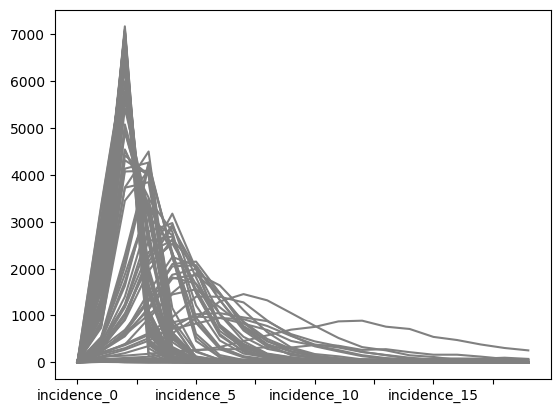

In [14]:
n_curves = 100
test_results.transpose().iloc[:,0:n_curves].plot( color='gray', legend=False )

## Running a single history matching iteration

#### Configuration

The first thing that we should do is to configure our history matching iteration. We do that by instantiating a `Config` object. The most basic instantiation (and configuration) uses only 3 parameters, as follows:

In [15]:
config = hm.Config( parameter_space = parameter_space.reset_index(),   # Get rid of "reset_index()"
                    observations = observations,
                    model = sir_model_wrapper
                   )

And with this configuration we can run one (or multiple) history matching iterations.

#### Running the iteration

We run a single history matching iteration by calling the function `do_step` and passing the instantiated configuration object. This function returns a trace of the history matching process. The trace is a list with items containing information about thd `do_step` calls (the first item contains information about the first call, the second item about the second call, and so on). The trace data for each `do_step` call includes the step or iteration number, the (trained) emulator bank, input data, and output sample, among other informational results. When running multiple steps of history matching, we should include the trace as an input parameter. If a trace is not included, a new one will be created by the `do_step` function. For example: 

```
trace_1  = do_step( config          )  # Runs the first step or iteration, and creates a new trace
trace_2  = do_step( config, trace_1 )  # Runs a second step, including all results up to the ones included in trace_1
trace_3  = do_step( config, trace_2 )  # Runs step 3
trace_3b = do_step( config, trace_2 )  # Runs step 3 again, but potentially changing the emulator target
```
In our example, we can do the first call to `do_step` as follows:

In [16]:
trace = hm.do_step( config )

Starting new History Matching iteration
... step_number = 1
... running simulator


Loading BokehJS ...

Please enter the feature or summary statistic to use as target for the emulator:  incidence_11


New samples generated |████████████████████████████████████████| 100.4% (a total of 8212 samples have been considered)
Remaining non-implausible space: 3.057%


## Check the iteration results

In [17]:
raise

RuntimeError: No active exception to reraise

In [ ]:
trace[0]['emulators']['incidence_11'].info()
trace[0]['emulators']['incidence_11'].plot_diagnostics()

In [ ]:
target_name = 'incidence_11'
target_mean = observations[ observations['feature']==target_name ]['mean'].values[0]
target_var  = observations[ observations['feature']==target_name ]['variance'].values[0]

x = trace[0]['test_points']
#x.loc[0,:] = [2.791925,  0.47125,    32250.0]
#x.loc[1,:] = [0.696125,  0.52525,    36750.0]
#x.loc[2,:] = [0.271975,  0.69175,    12750.0]

x.loc[0,:] = [3.99202,  0.3898,    16600.0]
x.loc[1,:] = [3.77246,  0.7210,    33000.0]
x.loc[2,:] = [0.49902,  0.8650,    65400.0]
x.loc[3,:] = [4.03194,  0.7606,    71000.0]
x.loc[4,:] = [0.13974,  0.3826,    86200.0]



pred = trace[0]['emulators'][target_name].predict( x )
implaus = trace[0]['emulators'][target_name].get_implausibility( trace[0]['test_points'], target_mean, target_var, 0 )
print(pred)
print('target_mean = ', target_mean)
fig,axs = plt.subplots(4,1, sharex=False)
axs[0].plot( trace[0]['test_points']['beta'], pred['value'], 'o' );  axs[0].set_title('predicted vs beta')
axs[1].plot( trace[0]['test_points']['gamma'], pred['value'], 'o' ); axs[1].set_title('predicted vs gamma')
axs[2].plot( trace[0]['test_points']['beta'], implaus, '.' );  axs[2].set_title('implausibility vs beta')
axs[3].plot( trace[0]['test_points']['gamma'], implaus, '.' );  axs[3].set_title('implausibility vs gamma')

print(implaus.sort_values( ascending=True ) )

In [ ]:
trace[0]['test_points']

In [ ]:
target_name = 'incidence_11'
target_mean = observations[ observations['feature']==target_name ]['mean'].values[0]
target_var  = observations[ observations['feature']==target_name ]['variance'].values[0]

trace[0]['emulators'][target_name].plot_implausibility( trace[0]['test_points'],
                                                        target_mean,
                                                        target_var
                                                       )

### Evaluating the performance of the emulator

In [ ]:
import logging
logging.basicConfig(level=logging.INFO)

config = hm.Config( parameter_space = parameter_space.reset_index(),
                    observations = observations,
                    model = sir_model_wrapper,
                    #sample_points = initial_samples,
                    #feature_selection_mode = 'manual',
                    candidates_per_iteration = n_samples,
                    #implausibility_threshold = 3,
                    #non_implausible_target = 0.01,
                    #model_discrepancy = 5
                   )

### Evaluating reductions in the parameter space

## Running multiple HM iterations

## HM calibration results

### Trajectory selection